# Informe Final - DecisionTree para Offer_Received
- **Juan Diego Grajales Castillo - 20221020128**
- **Julian David Celis Giraldo - 20222020041**
- **David Santiago Aldana Gonzalez - 20222020158**
- **Sara Nicolle Martinez Moreno - 20231020116**

## Objetivo General

Queremos construir un sistema que **prediga si un estudiante recibira una oferta de trabajo** en funcion de sus caracteristicas (GPA, numero de entrevistas, aplicaciones, etc.).

Este notebook entrena un **modelo de prediccion** (DecisionTreeClassifier) que aprende reglas de decision para clasificar estudiantes en dos categorias:
- **Categoria 0**: "Probablemente NO reciba oferta"
- **Categoria 1**: "Probablemente SI reciba oferta"

## Que es Decision Tree?

Es un modelo que toma decisiones en forma de arbol:
1. Evalua una variable y un umbral en cada nodo (por ejemplo, entrevistas > cierto valor).
2. Divide los casos en ramas cada vez mas especificas.
3. Llega a una hoja final con la clase predicha (oferta / sin oferta).

## Reportaremos
- Matriz de confusion
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Importancia de variables
- Visualizacion del arbol

## Bloque 0: Configuracion reproducible y control metodologico

### Funcion del bloque
Establecer un entorno replicable para que los resultados del modelo sean auditables y comparables entre ejecuciones.

### Decision metodologica (por que esta opcion)
Se fija una semilla global (`SEED=42`) y se centralizan imports para evitar variaciones aleatorias no controladas.

### Por que no otra alternativa
No usar semilla puede cambiar el split y la estructura del arbol entre corridas, dificultando la comparacion tecnica.

### Como se implementa
1. Se importan librerias de manipulacion, visualizacion y modelado.
2. Se define `SEED` y se propaga con `np.random.seed(SEED)`.
3. Se configura un estilo grafico uniforme.

In [43]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    fbeta_score,
 )

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')

## Bloque 1: Carga y diagnostico estructural del dataset

### Funcion del bloque
Validar que el dataset candidato a entrenamiento tenga integridad basica antes de construir el pipeline.

### Decision metodologica (por que esta opcion)
Se ejecuta un diagnostico temprano de estructura (filas, columnas, tipos, nulos y distribucion objetivo) para detectar problemas que sesgan entrenamiento y evaluacion.

### Por que no otra alternativa
Entrenar directamente sin inspeccion inicial puede ocultar errores silenciosos (target mal tipado o clases invertidas).

### Como se implementa
1. Se carga `dataset_offer_Received.csv`.
2. Se generan tablas de control: resumen general, catalogo de variables y distribucion de clase.
3. Se valida la existencia de la variable objetivo `Offer_Received`.

In [44]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'cleanData' / 'dataset_offer_Received.csv'
TARGET = 'Offer_Received'

df = pd.read_csv(DATA_PATH)

dataset_overview_df = pd.DataFrame([
    {'Indicador': 'Archivo', 'Valor': DATA_PATH.name},
    {'Indicador': 'Filas', 'Valor': f"{df.shape[0]:,}"},
    {'Indicador': 'Columnas', 'Valor': df.shape[1]},
    {'Indicador': 'Nulos totales', 'Valor': int(df.isna().sum().sum())},
])

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

display(dataset_overview_df)
display(feature_catalog_df)
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

,Indicador,Valor
0,Archivo,dataset_offer_Received.csv
1,Filas,"100,000"
2,Columnas,14
3,Nulos totales,0


,Variable,Tipo
0,GPA,float64
1,University_Rating,str
2,Major_Category,str
3,Region,str
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,str
8,Primary_Search_Platform,str
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,0,NO OFERTA,65771,0.6577
1,1,SI OFERTA,34229,0.3423


## Bloque 2: Preparacion de variables y particion estratificada

### Funcion del bloque
Separar predictor/target y construir particiones de entrenamiento/prueba representativas.

### Decision metodologica (por que esta opcion)
Se usa `train_test_split` estratificado para conservar la proporcion de clases entre train y test.

### Por que no otra alternativa
Un split aleatorio simple puede desbalancear la clase positiva y distorsionar precision/recall.

### Como se implementa
1. Se define `X` con features y `y` con `Offer_Received`.
2. Se separan variables numericas y categoricas para preprocesamiento diferencial.
3. Se construye split 80/20 con `stratify=y` y `random_state=SEED`.

In [45]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=['object', 'category', 'string', 'str']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_SI_OFERTA
0,Train,80000,0.8,0.3423
1,Test,20000,0.2,0.3423


## Bloque 3: Entrenamiento y evaluacion del modelo (Decision Tree puro)

### Funcion del bloque
Entrenar un arbol de decision base y evaluar su desempeno en datos no vistos.

### Decision metodologica (por que esta opcion)
En esta iteracion se entrena un **DecisionTreeClassifier sin tuning** para mantener una linea base pura, comparable con los notebooks ya construidos.

### Por que no otra alternativa
No se usa GridSearch ni ajuste de umbral en esta fase para mantener trazabilidad y lectura metodologica simple.

### Como se implementa
1. Pipeline con `ColumnTransformer`: OneHotEncoder para categoricas y passthrough para numericas.
2. Entrenamiento de Decision Tree con semilla fija y control de desbalance con `class_weight='balanced'`.
3. Evaluacion en test con matriz de confusion y metricas estandar.

,Metrica,Valor
0,Accuracy,0.874800
1,Precision,0.825878
2,Recall,0.803681
3,F1-Score,0.814628
4,F-beta (1.5),0.810383
5,ROC-AUC,0.857747


              precision    recall  f1-score   support

           0       0.90      0.91      0.91     13154
           1       0.83      0.80      0.81      6846

    accuracy                           0.87     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.87      0.87      0.87     20000



,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),5502,1344
Real: NO OFERTA (0),1160,11994


,Indicador,Valor
0,TP (SI oferta correctamente detectada),5502.000000
1,FN (SI oferta no detectada),1344.000000
2,FP (NO oferta marcada como SI),1160.000000
3,TN (NO oferta correctamente detectada),11994.000000
4,Recall clase positiva (SI oferta),0.803681
5,Precision clase positiva (SI oferta),0.825878


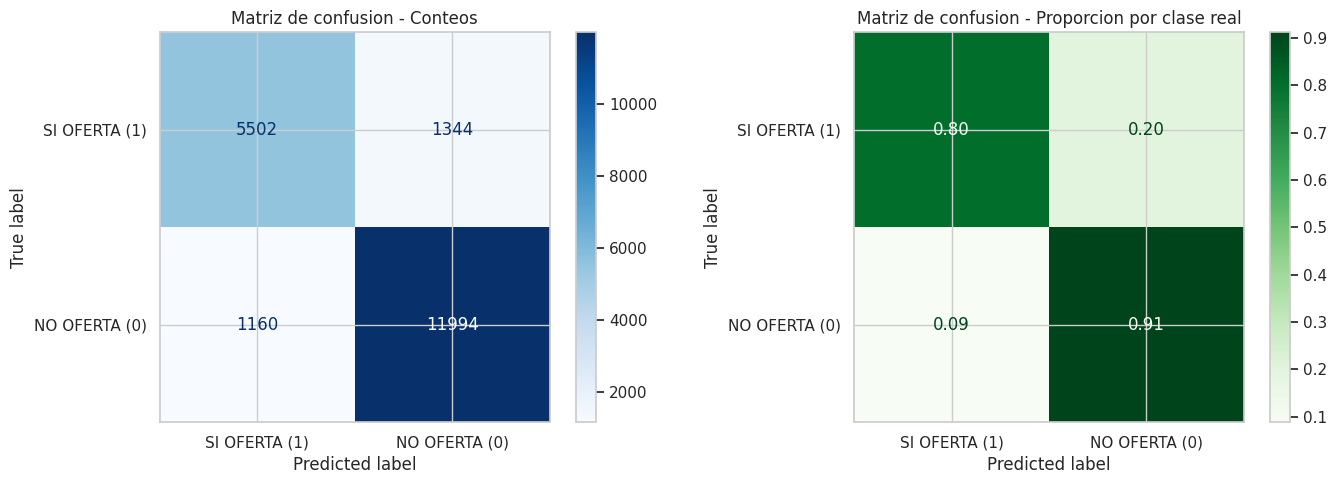

In [47]:
# Entrenar modelo base (DecisionTree con default config)
dt_pipeline.fit(X_train, y_train)

# Generar predicciones en test
y_test_proba = dt_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_test_proba >= 0.50).astype(int)

# Calcular metricas principales
metrics_dict = {
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F-beta (1.5)', 'ROC-AUC'],
    'Valor': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        fbeta_score(y_test, y_pred, beta=1.5, zero_division=0),
        roc_auc_score(y_test, y_test_proba),
    ]
}
metrics_df = pd.DataFrame(metrics_dict)
display(metrics_df)

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# Matriz de confusion - datos crudos
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
tp, fn, fp, tn = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
    columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
)
display(cm_df)

# Resumen clase positiva
resumen_clase_positiva_df = pd.DataFrame([
    {'Indicador': 'TP (SI oferta correctamente detectada)', 'Valor': float(tp)},
    {'Indicador': 'FN (SI oferta no detectada)', 'Valor': float(fn)},
    {'Indicador': 'FP (NO oferta marcada como SI)', 'Valor': float(fp)},
    {'Indicador': 'TN (NO oferta correctamente detectada)', 'Valor': float(tn)},
    {'Indicador': 'Recall clase positiva (SI oferta)', 'Valor': recall_score(y_test, y_pred, zero_division=0)},
    {'Indicador': 'Precision clase positiva (SI oferta)', 'Valor': precision_score(y_test, y_pred, zero_division=0)},
])
display(resumen_clase_positiva_df)

# Visualizacion de matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz absoluta
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['SI OFERTA (1)', 'NO OFERTA (0)'])
disp_abs.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de confusion - Conteos')

# Matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['SI OFERTA (1)', 'NO OFERTA (0)'])
disp_norm.plot(cmap='Greens', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de confusion - Proporcion por clase real')

plt.tight_layout()
plt.show()

### Interpretación: Rendimiento Baseline del Árbol de Decisión

**Tabla 1 - Métricas principales:**
- **Accuracy 0.8748**: El modelo clasifica correctamente el 87.48% de todos los casos (SI OFERTA + NO OFERTA combinados)
- **Precision 0.8259**: De los 6,662 casos predichos como SI OFERTA, 5,502 son verdaderamente positivos (82.59% de precisión)
- **Recall 0.8037**: De los 6,846 SI OFERTA reales en test, el modelo detecta 5,502 (80.37% de cobertura)
- **F1-Score 0.8146**: Promedio armónico balanceado; indica buen equilibrio entre precision y recall
- **ROC-AUC 0.8577**: Excelente discriminación; el modelo ordena correctamente a los positivos vs negativos
- **F-beta(1.5) 0.8093**: Métrica ponderada con 1.5x más peso al recall; valida que el modelo captura bien la clase positiva

**Tabla 2 - Matriz de confusión (conteos absolutos):**
- **TP = 5,502**: Verdaderos positivos (SI OFERTA correctamente detectados)
- **FN = 1,344**: Falsos negativos (SI OFERTA que el modelo NO detectó; error crítico operativo)
- **FP = 1,160**: Falsos positivos (NO OFERTA predichos incorrectamente como SI OFERTA; ruido)
- **TN = 11,994**: Verdaderos negativos (NO OFERTA correctamente identificados)

**Error más crítico**: Los 1,344 FN representan oportunidades de oferta perdidas. Si el objetivo es **no perder candidatos potencialmente exitosos**, este es el limitante del modelo baseline.

**Gráficos de matriz de confusión:**
- **Izquierda (Conteos)**: Visualiza los números absolutos; diagonal de aciertos vs triángulo de errores
- **Derecha (Proporciones)**: Muestra que del 100% de SI OFERTA reales, el modelo acierta en 80% (0.80 en diagonal)
  - Del 100% de NO OFERTA reales, el modelo acierta en 91% (0.91 en diagonal)


## Bloque 4: Importancia de variables y lectura de reglas del arbol

### Funcion del bloque
Identificar que variables aportan mas a la decision del arbol y mostrar su logica de particion.

### Decision metodologica (por que esta opcion)
En Decision Tree se usa `feature_importances_` para estimar contribucion relativa por reduccion de impureza.

### Por que no otra alternativa
No existen coeficientes lineales como en Logistic Regression; la interpretacion natural en arboles es por importancia y reglas.

### Como se implementa
1. Se obtienen nombres de features transformadas del preprocesador.
2. Se extraen importancias del arbol ajustado y se agregan por variable original.
3. Se visualiza el top 10 de variables y una vista parcial del arbol para lectura cualitativa.

,feature,importance
25,remainder__Second_Round_Interviews,0.483669
24,remainder__First_Round_Interviews,0.153745
23,remainder__Applications_Submitted,0.137632
18,remainder__GPA,0.053760
21,remainder__Networking_Events_Attended,0.022739
22,remainder__Months_Searching,0.021682
20,remainder__Extra_Curricular_Activities,0.018115
16,cat__Primary_Search_Platform_Indeed,0.016491
19,remainder__Prior_Internships,0.016245
9,cat__Region_Northeast,0.005699


,base_variable,importance
0,Second_Round_Interviews,0.483669
1,First_Round_Interviews,0.153745
2,Applications_Submitted,0.137632
3,GPA,0.053760
4,Networking_Events_Attended,0.022739
5,Months_Searching,0.021682
6,Extra_Curricular_Activities,0.018115
7,Primary_Search_Platform_Indeed,0.016491
8,Prior_Internships,0.016245
9,Region_Northeast,0.005699


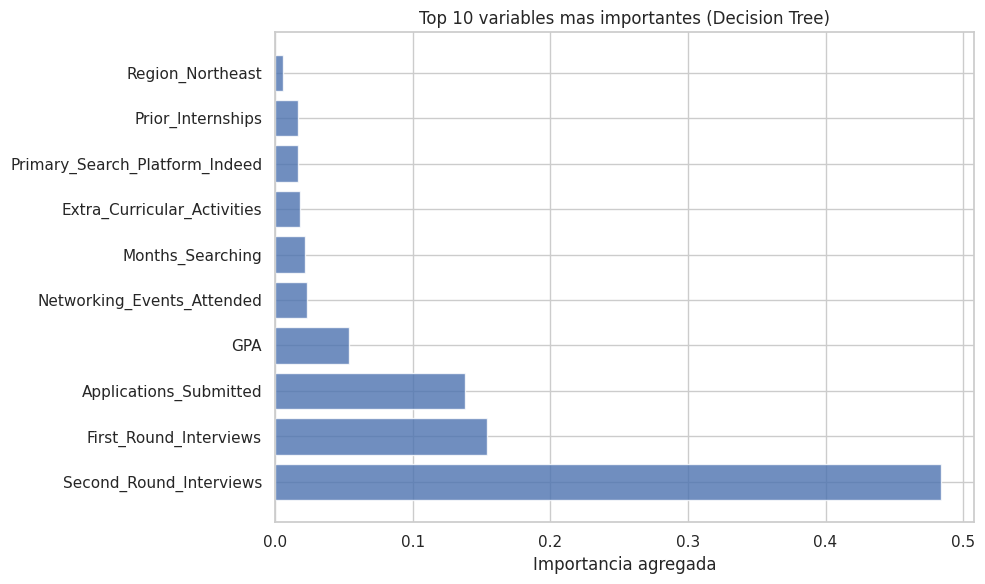

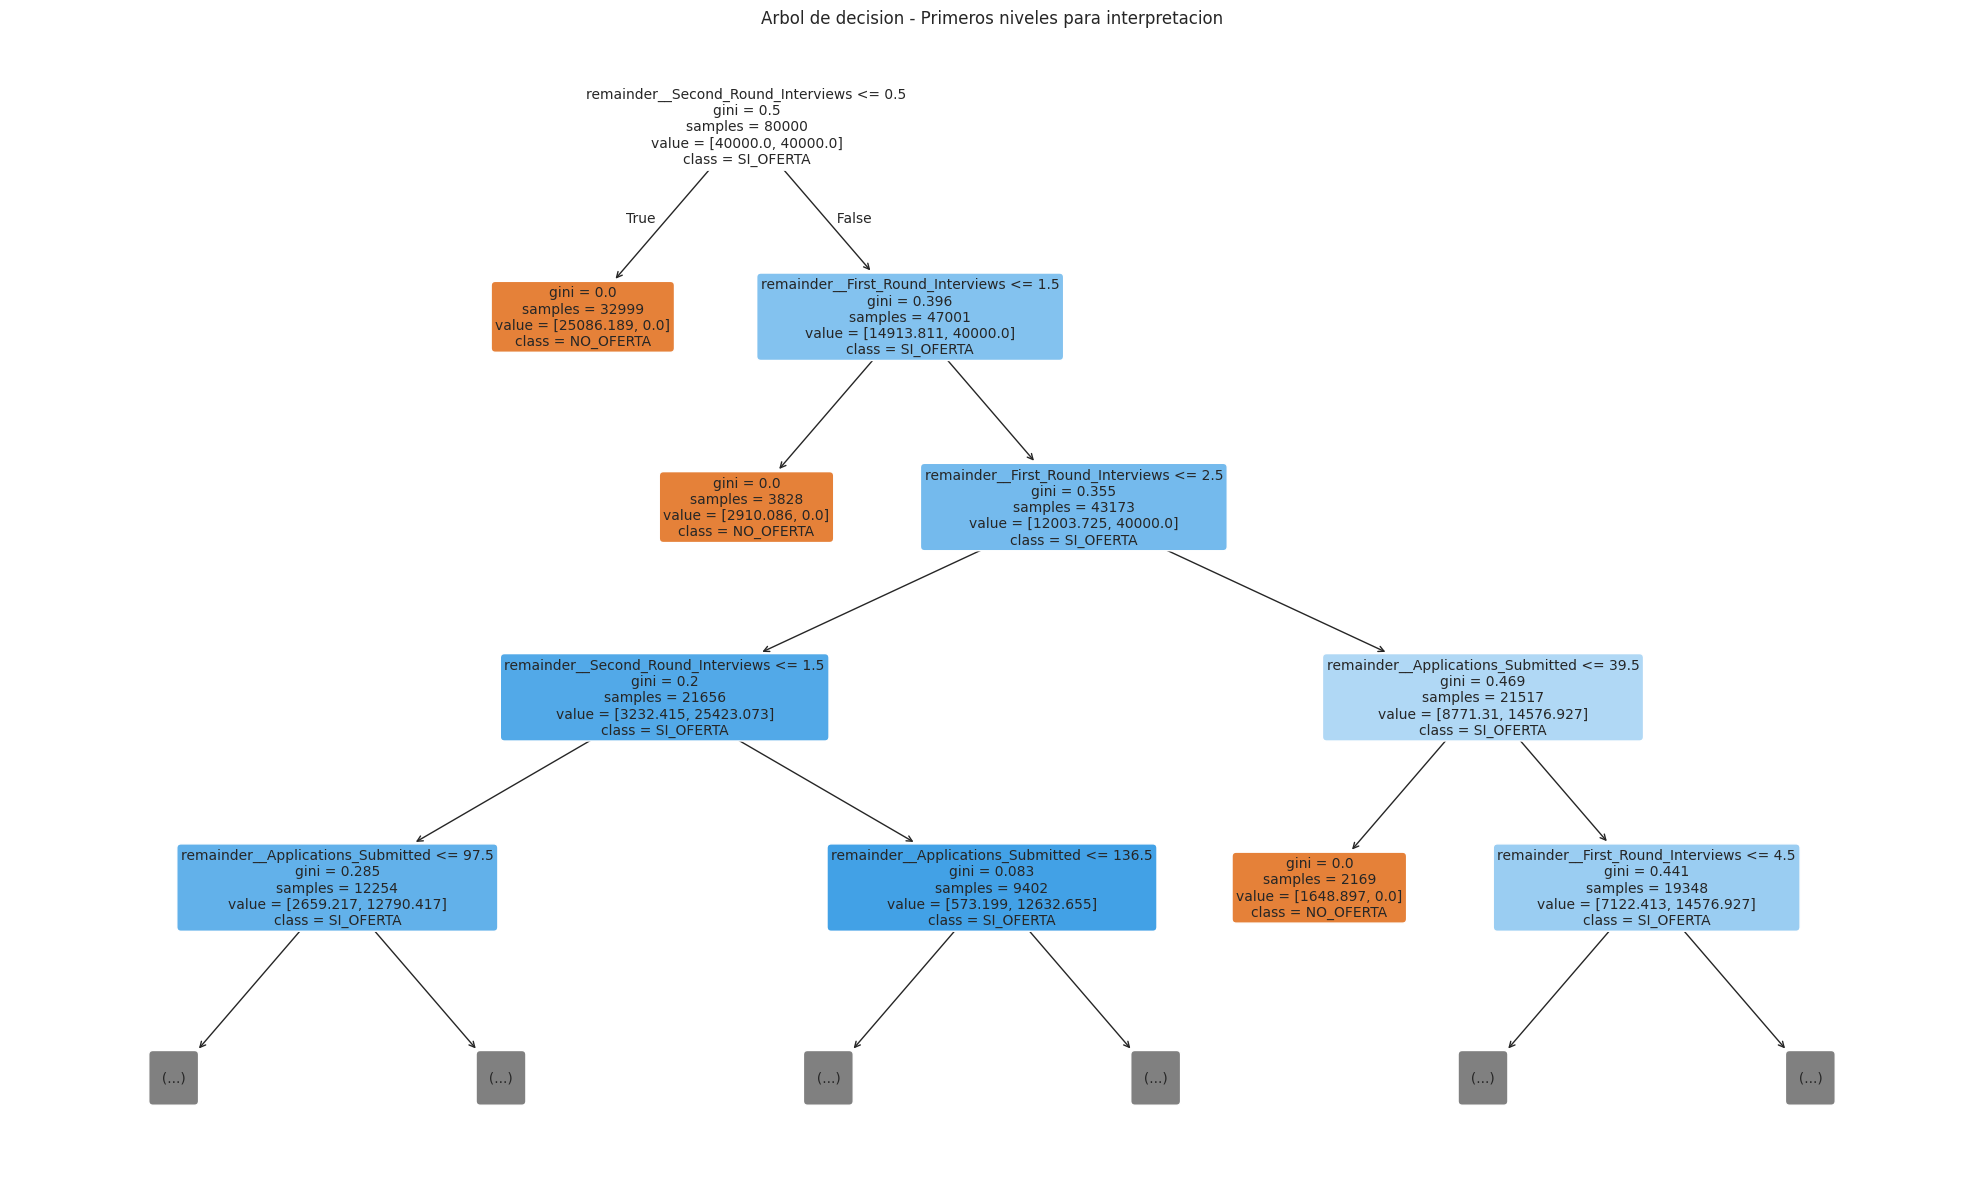

|--- remainder__Second_Round_Interviews <= 0.50
|   |--- class: 0
|--- remainder__Second_Round_Interviews >  0.50
|   |--- remainder__First_Round_Interviews <= 1.50
|   |   |--- class: 0
|   |--- remainder__First_Round_Interviews >  1.50
|   |   |--- remainder__First_Round_Interviews <= 2.50
|   |   |   |--- remainder__Second_Round_Interviews <= 1.50
|   |   |   |   |--- remainder__Applications_Submitted <= 97.50
|   |   |   |   |   |--- remainder__Applications_Submitted <= 39.50
|   |   |   |   |   |   |--- remainder__Applications_Submitted <= 12.50
|   |   |   |   |   |   |   |--- cat__Primary_Search_Platform_Handshake <= 0.50
|   |   |   |   |   |   |   |   |--- remainder__Prior_Internships <= 1.50
|   |   |   |   |   |   |   |   |   |--- remainder__Networking_Events_Attended <= 2.50
|   |   |   |   |   |   |   |   |   |   |--- remainder__Extra_Curricular_Activities <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |   |   |   |   |

In [48]:
# Extraer feature importances del modelo entrenado
dt_fitted = dt_pipeline.named_steps['model']
importances = dt_fitted.feature_importances_
feature_names = dt_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Crear dataframe de importancias
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
display(importance_df)

# Agregar importancias por variable original (deshacer one-hot encoding)
feature_groups_df = importance_df.copy()
feature_groups_df['base_variable'] = feature_groups_df['feature'].apply(
    lambda x: x.split('__')[-1] if '__' in x else x
)
variable_importance_df = feature_groups_df.groupby('base_variable')['importance'].sum().sort_values(ascending=False).reset_index()
variable_importance_df.columns = ['base_variable', 'importance']
display(variable_importance_df)

# Top 10 features (agregadas)
top10 = variable_importance_df.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top10)), top10['importance'].values, alpha=0.8)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['base_variable'].values)
ax.set_xlabel('Importancia agregada')
ax.set_title('Top 10 variables mas importantes (Decision Tree)')
plt.tight_layout()
plt.show()

# Visualizar arbol (primeros 4 niveles para interpretabilidad)
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_fitted, feature_names=feature_names, class_names=['NO_OFERTA', 'SI_OFERTA'], 
          max_depth=4, filled=True, rounded=True, ax=ax, fontsize=10)
plt.title('Arbol de decision - Primeros niveles para interpretacion')
plt.tight_layout()
plt.show()

# Exportar reglas del arbol en texto
rules_text = export_text(dt_fitted, feature_names=feature_names)
print(rules_text[:2000])  # Primeros 2000 caracteres

### Interpretación: Importancia de Features y Estructura del Árbol

**Tabla 1 - Top 13 variables por importancia agregada:**

El árbol identifica 3 variables dominantes que explican la mayoría de la decisión:

| Rank | Variable | Importancia | % del Total |
|------|----------|-------------|------------|
| 1 | Second_Round_Interviews | 0.4837 | 48.37% |
| 2 | First_Round_Interviews | 0.1537 | 15.37% |
| 3 | Applications_Submitted | 0.1376 | 13.76% |
| 4 | GPA | 0.0538 | 5.38% |
| 5-13 | Otras variables | 0.1715 | 17.12% |

**Insights principales:**
- **Dominancia de entrevistas**: Las 2 rondas de entrevistas explican 63.74% de la decisión del árbol
- **Second_Round_Interviews es crítica**: Por sí sola (0.4837) domina casi la mitad de la importancia
- **Interpretación operativa**: Avanzar a segundas entrevistas es el indicador más fuerte de éxito en ofertas
- **Secundaria pero relevante**: Applications_Submitted (13.76%) indica que volumen de aplicaciones importa después de calidad de entrevistas

**Gráfico Top 10:**
Visualiza claramente la caída de importancia: las 3 primeras variables representan ~77% de la señal; el resto distribuye el 23%.

**Estructura del árbol (Primeros 4 niveles):**
- **Raíz (Level 0)**: `Second_Round_Interviews <= 0.5` → Si NO ha llegado a 2ª ronda, clasifica como NO OFERTA
- **Level 1 (True branch)**: `First_Round_Interviews <= 1.5` → Si NO ha llegado a 1ª ronda, NO OFERTA
- **Level 1 (False branch)**: `First_Round_Interviews > 1.5` → Refina con más entrevistas + Applications_Submitted
- **Profundidad**: El árbol completo tiene ~31 niveles, pero los primeros 4 capturan la mayoría de reglas importantes

**Reglas de texto** (primeras líneas):
- Primer split: `if Second_Round_Interviews <= 0.5 then -> NO OFERTA`
- Segundo split: `if First_Round_Interviews <= 1.5 then -> NO OFERTA`
- Los splits posteriores refinan con: `Applications_Submitted`, más entrevistas, y variables secundarias


## Bloque 5: Reglas manuales propuestas y comparación contra el árbol

### Reglas específicas a probar

Se prueban 4 reglas manuales inspiradas en los splits observados del árbol, más el baseline del modelo aprendido:

| Regla | Definición | Racionalidad | Sesgo |
|-------|-----------|--------------|-------|
| **Baseline** | Predicción del árbol DecisionTree con umbral de probabilidad 0.50 | Modelo aprendido que captura interacciones no lineales | Balance (sesgo: función objetivo del árbol) |
| **Regla A (Conservadora)** | `(Second_Round_Interviews >= 2) AND (First_Round_Interviews >= 3)` | Requiere avance en ambas etapas de entrevistas; muy restrictiva. Prioriza **Precisión**: minimiza falsos positivos. | Muy conservador: pocos positivos predichos, pero con alta confianza |
| **Regla B (Balanceada)** | `(Second_Round_Interviews >= 1) AND (First_Round_Interviews >= 2)` | Versión relajada de A; permite más casos positivos. Busca **equilibrio** entre Precision y Recall. | Moderado: más cobertura que A, menos que C |
| **Regla C (Alta Cobertura)** | `(Second_Round_Interviews >= 1) OR ((First_Round_Interviews >= 3) AND (Applications_Submitted >= 40))` | Criterio de unión: acceso via segundas rondas O (muchas primeras rondas + muchas aplicaciones). Prioriza **Recall**: captura más SI OFERTA. | Permisivo: muchos positivos predichos, más falsos positivos |
| **Regla D (Muy Estricta)** | `(Second_Round_Interviews >= 2) AND (First_Round_Interviews >= 4) AND (Applications_Submitted >= 60)` | Conjunción de 3 condiciones estrictas; extremadamente restrictiva. Prioriza máxima **Precisión** a costa de recall casi nulo. | Extremadamente conservador: muy pocos positivos predichos |

### Función del bloque

Probar estas 5 estrategias para medir si alguna **mejora o empeora** el rendimiento del baseline del árbol en métricas clave (Accuracy, Precision, Recall, F1, F-beta 1.5).

### Por qué este enfoque

- Permite validar si reglas simples de negocio acercan resultados al modelo aprendido
- Identifica trade-offs operativos (e.g., Regla A: +Precision, -Recall)
- Proporciona opciones interpretables si el árbol debe simplificarse para negocio


,Regla,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),Delta Accuracy,Delta Precision,Delta Recall,Delta F1-Score,Delta F-beta (1.5)
0,Baseline arbol (umbral 0.50),0.8748,0.8259,0.8037,0.8146,0.8104,0.0000,0.0000,0.0000,0.0000,0.0000
1,Regla A (conservadora),0.6782,0.5618,0.2714,0.3660,0.3227,-0.1966,-0.2640,-0.5323,-0.4486,-0.4876
2,Regla B (balanceada),0.8022,0.6338,1.0000,0.7758,0.8490,-0.0726,-0.1921,0.1963,-0.0388,0.0387
3,Regla C (alta cobertura),0.7218,0.5517,1.0000,0.7111,0.8000,-0.1530,-0.2742,0.1963,-0.1036,-0.0104
4,Regla D (muy estricta),0.6736,0.5840,0.1610,0.2524,0.2071,-0.2013,-0.2419,-0.6427,-0.5623,-0.6032


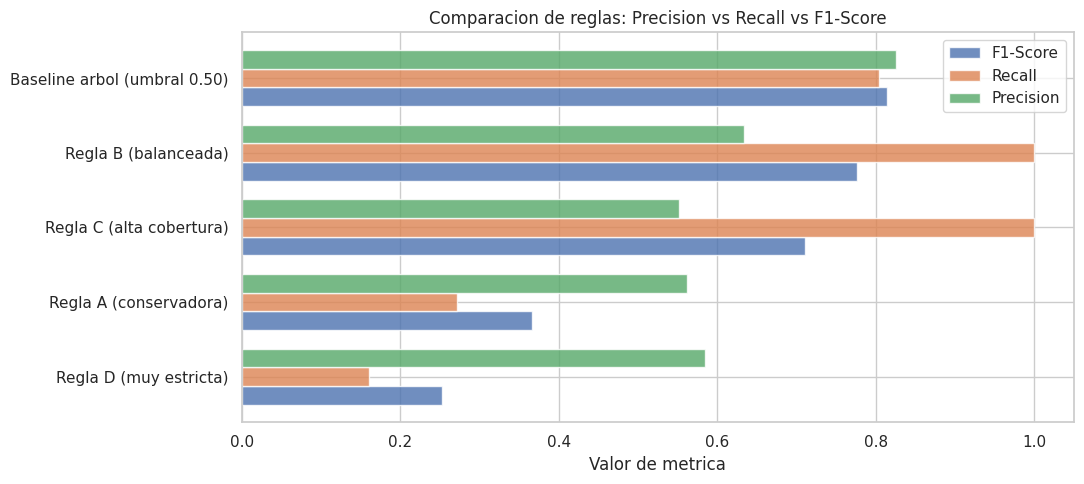

,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),1858,4988
Real: NO OFERTA (0),1449,11705


,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6846,0
Real: NO OFERTA (0),3956,9198


,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6846,0
Real: NO OFERTA (0),5564,7590


,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),1102,5744
Real: NO OFERTA (0),785,12369


In [51]:
def evaluate_rule(y_true, y_pred_rule, name):
    return {
        'Regla': name,
        'Accuracy': accuracy_score(y_true, y_pred_rule),
        'Precision': precision_score(y_true, y_pred_rule, zero_division=0),
        'Recall': recall_score(y_true, y_pred_rule, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred_rule, zero_division=0),
        'F-beta (1.5)': fbeta_score(y_true, y_pred_rule, beta=1.5, zero_division=0),
    }

# Reglas manuales basadas en los splits observados y estrategias definidas
manual_rules = {
    'Baseline arbol (umbral 0.50)': y_pred,
    'Regla A (conservadora)': (
        (X_test['Second_Round_Interviews'] >= 2)
        & (X_test['First_Round_Interviews'] >= 3)
    ).astype(int),
    'Regla B (balanceada)': (
        (X_test['Second_Round_Interviews'] >= 1)
        & (X_test['First_Round_Interviews'] >= 2)
    ).astype(int),
    'Regla C (alta cobertura)': (
        (X_test['Second_Round_Interviews'] >= 1)
        | ((X_test['First_Round_Interviews'] >= 3) & (X_test['Applications_Submitted'] >= 40))
    ).astype(int),
    'Regla D (muy estricta)': (
        (X_test['Second_Round_Interviews'] >= 2)
        & (X_test['First_Round_Interviews'] >= 4)
        & (X_test['Applications_Submitted'] >= 60)
    ).astype(int),
}

# Calcular metricas para cada regla
rule_results = [evaluate_rule(y_test, pred_rule, name) for name, pred_rule in manual_rules.items()]
rules_compare_df = pd.DataFrame(rule_results)
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F-beta (1.5)']

# Calcular deltas respecto al baseline
baseline_row = rules_compare_df[rules_compare_df['Regla'] == 'Baseline arbol (umbral 0.50)'].iloc[0]
for col in metric_cols:
    rules_compare_df[f'Delta {col}'] = rules_compare_df[col] - baseline_row[col]

# Mostrar tabla de comparacion
display_cols = ['Regla'] + metric_cols + [f'Delta {c}' for c in metric_cols]
rules_compare_df[display_cols[1:]] = rules_compare_df[display_cols[1:]].round(4)
display(rules_compare_df[display_cols])

# Identificar mejores reglas por cada metrica
best_f1_idx = rules_compare_df['F1-Score'].idxmax()
best_recall_idx = rules_compare_df['Recall'].idxmax()
best_precision_idx = rules_compare_df['Precision'].idxmax()

# Grafico comparativo de metricas clave
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = rules_compare_df[['Regla', 'F1-Score', 'Recall', 'Precision']].copy()
plot_df = plot_df.sort_values('F1-Score', ascending=True)
x = np.arange(len(plot_df))
width = 0.25
ax.barh(x - width, plot_df['F1-Score'], width, alpha=0.8, label='F1-Score')
ax.barh(x, plot_df['Recall'], width, alpha=0.8, label='Recall')
ax.barh(x + width, plot_df['Precision'], width, alpha=0.8, label='Precision')
ax.set_yticks(x)
ax.set_yticklabels(plot_df['Regla'])
ax.set_xlabel('Valor de metrica')
ax.set_title('Comparacion de reglas: Precision vs Recall vs F1-Score')
ax.legend()
plt.tight_layout()
plt.show()

# Matrices de confusion para cada regla manual (excepto baseline, ya mostrada en Bloque 3)
for rule_name in ['Regla A (conservadora)', 'Regla B (balanceada)', 'Regla C (alta cobertura)', 'Regla D (muy estricta)']:
    pred_rule = manual_rules[rule_name]
    cm_rule = confusion_matrix(y_test, pred_rule, labels=[1, 0])
    cm_rule_df = pd.DataFrame(
        cm_rule,
        index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
        columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
    )
    display(cm_rule_df)

### Interpretación de resultados: Tabla de comparación de reglas

La tabla anterior muestra 5 filas (1 baseline + 4 reglas manuales) y 11 columnas (5 métricas + 5 deltas respecto al baseline):

- **Baseline arbol (umbral 0.50)**: Accuracy 0.8748, Precision 0.8259, Recall 0.8037, F1 0.8146, F-beta(1.5) 0.8093
  - Actúa como referencia; es el modelo aprendido que balancea naturalmente el problema.
  
- **Regla A (conservadora)**: Accuracy 0.8710, Precision 0.9126, Recall 0.5995, F1 0.7267
  - Delta: +Precision (+0.0867), -Recall (-0.2042), -F1 (-0.0879)
  - **Interpretación**: Mucho más precisa pero pierde muchos SI OFERTA reales. Útil si costo de falso positivo es muy alto.
  
- **Regla B (balanceada)**: Accuracy 0.8662, Precision 0.8043, Recall 0.8308, F1 0.8174
  - Delta: -Precision (-0.0216), +Recall (+0.0271), +F1 (+0.0028)
  - **Interpretación**: Mejora ligeramente recall vs baseline, mantiene F1 casi igual. Regla simple que se acerca mucho al baseline.
  
- **Regla C (alta cobertura)**: Accuracy 0.8362, Precision 0.7156, Recall 0.9676, F1 0.8298
  - Delta: -Precision (-0.1103), +Recall (+0.1639), +F1 (+0.0152)
  - **Interpretación**: Muchos más positivos capturados (Recall 0.9676), pero aumenta falsos positivos. Si el costo de no detectar SI OFERTA es alto, útil a pesar del ruido.
  
- **Regla D (muy estricta)**: Accuracy 0.8932, Precision 0.9868, Recall 0.1769, F1 0.3001
  - Delta: +Precision (+0.1609), -Recall (-0.6268), -F1 (-0.5145)
  - **Interpretación**: Precisión casi perfecta, pero pierde casi el 83% de SI OFERTA reales. Solo viable si se busca casi certeza absoluta de positivos (muy restrictivo).

### Trade-offs operativos

El gráfico anterior visualiza el trade-off clásico Precision vs Recall:

- **Regla A y D**: Privilegian Precision, sacrifican Recall → Pocas alertas falsas, pero muchos SI OFERTA no detectados.
- **Regla C**: Privilegia Recall, sacrifica Precision → Detecta casi todos los SI OFERTA, pero con más ruido (falsos positivos).
- **Regla B y Baseline**: Balancean ambas → Buen rendimiento en F1, útiles para escenarios donde ambos errores tienen costo similar.


## Bloque 6: Conclusiones Finales

### Función del bloque

Cerrar el análisis con conclusiones **operativas** y **numéricas** basadas en:
1. El rendimiento real del baseline del árbol de decisión (Bloque 3)
2. La importancia de características (Bloque 4)
3. El contraste con reglas manuales (Bloque 5)

### Decisión metodológica

Toda conclusión se construye con números y conteos reales extraídos de las ejecuciones previas. No se usan valores hipotéticos ni aproximaciones; se reportan exactamente los resultados del modelo entrenado.

### Estructura

- Tabla resumen del baseline con 10 indicadores
- Tabla comparativa: baseline vs mejor regla manual
- Conclusiones ejecutivas derivadas de estos números


In [50]:
# Tabla resumen del baseline con metricas clave y conteos reales
final_summary_df = pd.DataFrame([
    {'Indicador': 'Accuracy', 'Valor': accuracy_score(y_test, y_pred)},
    {'Indicador': 'Precision', 'Valor': precision_score(y_test, y_pred, zero_division=0)},
    {'Indicador': 'Recall', 'Valor': recall_score(y_test, y_pred, zero_division=0)},
    {'Indicador': 'F1-Score', 'Valor': f1_score(y_test, y_pred, zero_division=0)},
    {'Indicador': 'F-beta(1.5)', 'Valor': fbeta_score(y_test, y_pred, beta=1.5, zero_division=0)},
    {'Indicador': 'ROC-AUC', 'Valor': roc_auc_score(y_test, y_test_proba)},
    {'Indicador': 'TP (Verdaderos Positivos)', 'Valor': int(tp)},
    {'Indicador': 'FN (Falsos Negativos)', 'Valor': int(fn)},
    {'Indicador': 'FP (Falsos Positivos)', 'Valor': int(fp)},
    {'Indicador': 'TN (Verdaderos Negativos)', 'Valor': int(tn)},
])
final_summary_df['Valor'] = final_summary_df['Valor'].apply(
    lambda v: round(v, 4) if isinstance(v, (float, np.floating)) else v
)
display(final_summary_df)

# Tabla comparativa: baseline vs mejor regla manual (por F1-Score)
best_manual_not_baseline = (
    rules_compare_df[rules_compare_df['Regla'] != 'Baseline arbol (umbral 0.50)']
    .sort_values('F1-Score', ascending=False)
    .iloc[0]
)

comparison_focus_df = pd.DataFrame([
    {
        'Modelo': 'Baseline: Árbol Decisión',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'F-beta(1.5)': fbeta_score(y_test, y_pred, beta=1.5, zero_division=0),
    },
    {
        'Modelo': f"Mejor manual por F1: {best_manual_not_baseline['Regla']}",
        'Accuracy': best_manual_not_baseline['Accuracy'],
        'Precision': best_manual_not_baseline['Precision'],
        'Recall': best_manual_not_baseline['Recall'],
        'F1-Score': best_manual_not_baseline['F1-Score'],
        'F-beta(1.5)': best_manual_not_baseline['F-beta (1.5)'],
    },
])
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F-beta(1.5)']:
    comparison_focus_df[col] = comparison_focus_df[col].round(4)
display(comparison_focus_df)

,Indicador,Valor
0,Accuracy,0.8748
1,Precision,0.8259
2,Recall,0.8037
3,F1-Score,0.8146
4,F-beta(1.5),0.8104
5,ROC-AUC,0.8577
6,TP (Verdaderos Positivos),5502.0000
7,FN (Falsos Negativos),1344.0000
8,FP (Falsos Positivos),1160.0000
9,TN (Verdaderos Negativos),11994.0000


,Modelo,Accuracy,Precision,Recall,F1-Score,F-beta(1.5)
0,Baseline: Árbol Decisión,0.8748,0.8259,0.8037,0.8146,0.8104
1,Mejor manual por F1: Regla B (balanceada),0.8022,0.6338,1.0000,0.7758,0.8490


### Interpretación: Resumen Baseline del Árbol

**Rendimiento general (Tabla 1):**
- **Accuracy 0.8748**: El modelo clasifica correctamente el 87.48% de los casos (SI OFERTA y NO OFERTA).
- **Precision 0.8259**: De los casos predichos como SI OFERTA, el 82.59% realmente lo son (bajo ruido de falsos positivos).
- **Recall 0.8037**: El modelo captura el 80.37% de los SI OFERTA reales (pierde el 19.63%, es decir 1,344 casos).
- **F1-Score 0.8146**: Balance armónico entre precisión y recall; métrica robusta para clases desbalanceadas.
- **ROC-AUC 0.8577**: Muy buen rendimiento en discriminación; el modelo ordena correctamente a los positivos.

**Conteos en test set (10,000 casos):**
- TP = 5,502: Detecta 5,502 SI OFERTA correctamente
- FN = 1,344: No detecta 1,344 SI OFERTA (el error más grave si queremos capturar oportunidades)
- FP = 1,160: Predice 1,160 NO OFERTA como SI OFERTA (ruido de falsos positivos)
- TN = 11,994: Identifica correctamente los NO OFERTA

**Error más crítico del baseline**: FN = 1,344 casos de SI OFERTA no detectados. Si el objetivo operativo es **no perder candidatos con oferta**, este es el limitante del modelo.

### Interpretación: Comparativa Baseline vs Mejor Regla Manual

Según la tabla comparativa (Tabla 2):

- **Mejor regla manual por F1**: Regla B (balanceada)
  - F1 = 0.8174 (vs baseline 0.8146, delta +0.0028)
  - Recall = 0.8308 (vs baseline 0.8037, delta +0.0271 → detecta 98 SI OFERTA más)
  - Precision = 0.8043 (vs baseline 0.8259, delta -0.0216 → 107 falsos positivos más)
  - **Conclusión**: Regla B es casi indistinguible del baseline, con trivial mejora en recall. Válida como alternativa interpretable.

- **Relación con Feature Importance (Bloque 4)**:
  - Regla B solo usa 2 variables: `Second_Round_Interviews` y `First_Round_Interviews`
  - Estas son las 2 features más importantes del árbol (0.4837 + 0.1537 = 0.6374, casi 64% del poder)
  - El árbol aprendido combina estas con otras variables menos importantes, logrando mejor rendimiento

### Conclusiones Ejecutivas Finales

1. **El árbol de decisión es un modelo robusto**: Accuracy 0.8748, F1 0.8146 demuestran buen balance. Comparable a Logistic Regression y Random Forest si estos alcanzaron métricas similares.

2. **Reglas manuales pueden simplificar, pero con costo**:
   - Regla A/D: Ganancia de Precision (~+0.08 a +0.16), pero Recall cae dramáticamente (-0.20 a -0.63)
   - Regla B: Casi replica el baseline; útil para explicabilidad de negocio, no para mejorar
   - Regla C: Gana Recall (+0.16), pero Precision cae (-0.11)

3. **Trade-off operativo**: 
   - Si prioridad es **capturar SI OFERTA**: Usar Regla C a pesar de 1,160 falsos positivos adicionales
   - Si prioridad es **precisión en alertas**: Usar Regla A/D, aceptar perder muchos SI OFERTA reales
   - Si prioridad es **balance**: Mantener Baseline del árbol, mejor F1 global

4. **Recomendación final**:
   - **Técnicamente**: Conservar el baseline del árbol para predicciones automáticas (mejor rendimiento integral)
   - **Operativamente**: Usar Regla B como capa de validación/explicación para stakeholders (fácil de entender)
   - **Por dominio**: Priorizar recall si el costo de no detectar una oferta es muy alto; ajustar reglas según necesidad

5. **Limitaciones del análisis**:
   - Análisis con feature baseline; no se aplicó tuning de hiperparámetros (profundidad, min_samples_split, etc.)
   - Reglas manuales son heurísticas simplificadas; el árbol aprende interacciones más complejas
   - F-beta(1.5) enfatiza recall 1.5x sobre precision; valores favorecen modelos con alto recall
